# ZeroJudge APCS Practice Questions

題目來源：ZeroJudge/APCS 截圖整理。這份 notebook 只放題目與練習區，不放完整答案。

## f163. 貨物分配

有一個貨物分配系統，可以看成一棵二元樹。

- 編號 `1 ~ n-1` 是分裝站。
- 編號 `n ~ 2n-1` 是儲貨站。
- 每個分裝站都有左、右兩個子節點。

每次有一個新貨物從編號 `1` 的分裝站進入。到達某個分裝站時：

1. 計算左子樹目前的貨物總重量。
2. 計算右子樹目前的貨物總重量。
3. 貨物會往總重量較小的一邊走。
4. 如果左右一樣重，往左邊走。
5. 最後抵達某個儲貨站後，輸出該儲貨站編號，並把該貨物重量加到路徑上的總重量中。

### 輸入

第一行：`n m`

第二行：`n` 個整數，代表儲貨站 `n ~ 2n-1` 一開始已有的重量。

第三行：`m` 個整數，代表依序要放入系統的貨物重量。

接下來 `n-1` 行，每行 `a b c`，代表分裝站 `a` 的左子節點是 `b`，右子節點是 `c`。

### 輸出

輸出 `m` 個數字，代表每個貨物最後放入的儲貨站編號。

### Sample Input #1

```text
7 2
9 2 1 6 7 4 5
2 3
1 2 5
2 3 7
3 13 10
4 9 11
6 12 8
5 6 4
```

### Sample Output #1

```text
8 12
```

### 練習提示

先把每個節點的「子樹總重量」算出來。每放入一個貨物，就沿著路徑往下走，最後再把路徑上每個節點的總重量都加上貨物重量。

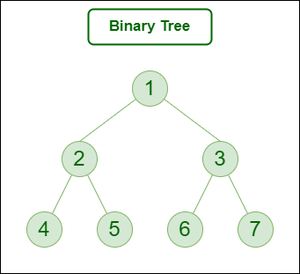

n = 4 -> 3 個分裝站； 4個貨櫃

In [ ]:
# f163 練習區
import sys

def solve(data: str) -> str:
    nums = list(map(int, data.split()))
    idx = 0

    n = nums[idx]
    m = nums[idx+1]
    idx += 2

    weight = [0] * (2 * n)

    for node in range(n, 2 * n):
        weight[node] = nums[idx]
        idx += 1

    cargos = nums[idx: idx + m]
    idx += m

    left = [0] * (2 * n)
    right = [0] * (2 * n)

    for _ in range(n-1):
        a, b, c = nums[idx:idx+3]
        idx += 3

        left[a] = b
        right[a] = c

    stack = [(1,False)]

    while stack:
        node, visited = stack.pop()

        if node >= n:
            continue

        if not visited:

            stack.append(node, True)

            stack.append(left[node], False)
            stack.append(right[node], False)
        
        else:
            weight[node] = weight[left[node]] + weight[right[node]]

    outputs = []

    for cargo in cargos:
        node = 1
        path = []

        while node < n:
            path.append(node)

            l, r = left[node], right[node]

            if weight[l] <= weight[r]:
                node = l
            else:
                node = r

    outputs.append(str(node))

    weight[node] += cargo

    for p in path:
        weight[p] += cargo
    
    return ' '.join(outputs)


# print(solve(sys.stdin.read()))

## f312. 人力分配

有一家公司有 `n` 個員工，還有兩個工廠。

如果工廠一分到 `X1` 個員工，收益為：

$$Y_1 = A_1 X_1^2 + B_1 X_1 + C_1$$

如果工廠二分到 `X2` 個員工，收益為：

$$Y_2 = A_2 X_2^2 + B_2 X_2 + C_2$$

每個員工都必須分配到其中一個工廠。請找出最大總收益。

### 輸入

第一行：`A1 B1 C1`

第二行：`A2 B2 C2`

第三行：`n`

### 輸出

輸出最大收益。

### Sample Input #1

```text
2 -1 3
4 -5 2
2
```

### Sample Output #1

```text
11
```

### 練習提示

`n <= 100`，可以枚舉工廠一分到 `0 ~ n` 個員工，工廠二就是 `n - x`。

Y_1 + Y_2 => optimization （最佳化）

In [8]:
# f312 練習區
import sys

def solve(data: str) -> str:
    nums = list(map(int, data.split()))
    A1, B1, C1 = nums[0:3]
    A2, B2, C2 = nums[3:6]
    n = nums[6]

    best = None

    for x1 in range(n+1):
        x2 = n - x1

        y1 = A1 * (x1 **2) + B1 * x1 + C1
        y2 = A2 * (x2 **2) + B2 * x2 + C2
        total = y1 + y2

        if best is None or total > best:
            best = total
    
    return str(best)

# print(solve(sys.stdin.read()))

In [9]:
solve("2 -1 3 4 -5 2 2")

'11'

## f605. 購買力

市場上有 `n` 個商品，已知每個商品最近三天的價格。

你想購買「近期價格波動夠大」的商品：

- 對某個商品，如果最近三天的最高價與最低價相差至少 `d`，就購買。
- 購買成本是該商品最近三天價格的平均值。
- 題目保證平均值是整數。

請輸出購買的商品數量以及總成本。

### 輸入

第一行：`n d`

接下來 `n` 行，每行三個整數，代表某商品最近三天價格。

### 輸出

輸出兩個整數：購買商品數量、總成本。

### Sample Input #1

```text
1 3
24 27 21
```

### Sample Output #1

```text
1 24
```

### Sample Input #2

```text
3 4
24 33 42
51 48 60
77 77 77
```

### Sample Output #2

```text
2 86
```

In [ ]:
# f605 練習區
import sys

def solve(data: str) -> str:
    nums = list(map(int, data.split()))
    
    idx = 0
    n = nums[idx]
    d = nums[idx + 1]
    idx += 2

    count = 0
    total_score = 0

    for _ in range(n):
        prices = nums[idx: idx + 3]
        idx += 3

        if max(prices) - min(prices) >= d:
            count += 1
            total_score += sum(prices) // 3
            
    return f"{count} {total_score}"

# print(solve(sys.stdin.read()))

## g275. 七言對聯

中文依照發音方式可以分為平聲與仄聲，題目中：

- `0` 代表平聲
- `1` 代表仄聲

一個七言對聯有兩句，每句 7 個字。請判斷每組對聯違反哪些規則。

### 三個規則

A. 二四不同、二六同：每一句的第 2、4 個字平仄必須不同；第 2、6 個字平仄必須相同。

B. 仄起平收：第一句最後一個字必須是仄聲，第二句最後一個字必須是平聲。

C. 上下相對：第一句與第二句的第 2、4、6 個字平仄必須不同。

### 輸入

第一行：`n`，代表有 `n` 組對聯。

接下來每組有兩行，每行 7 個 `0/1`。

### 輸出

每組輸出一行：

- 違反哪些規則，就依序輸出 `A`、`B`、`C`。
- 如果都沒有違反，輸出 `None`。

### Sample Input #1

```text
1
1 1 0 0 0 1 1
1 0 0 0 1 1 0
```

### Sample Output #1

```text
AC
```

### Sample Input #2

```text
1
0 1 1 0 1 1 1
1 0 1 1 0 0 0
```

### Sample Output #2

```text
None
```

In [ ]:
# g275 練習區
import sys

def violate_A(lines):
    return not(lines[1] != lines[3] and lines[1] == lines[5])


def solve(data: str) -> str:
    nums = list(map(int, data.split()))
    idx = 0
    n = nums[idx]
    idx += 1

    ans = []
    for _ in range(n):
        first = nums[idx: idx + 7]
        idx += 7

        second = nums[idx: idx + 7]
        idx += 7

        bad = ''

        if violate_A(first) or violate_A(second):
            bad += 'A'

        if not (first[-1] == 1 and second == 0):
            bad += "B"

        if not (first[1] != second[1] and 
                first[3] != second[3] and 
                first[5] != second[5]):
            
            bad += "C"

        ans.append(bad if bad else "None")

    return "\n".join(ans)

        
# print(solve(sys.stdin.read()))

## g595. 修補圍籬

有一個農場有寬度為 `n` 的圍籬，每個位置原本都有高度 `h[i]`。

有些圍籬被風吹斷，輸入中高度會變成 `0`。題目保證不會有兩個相鄰的壞掉圍籬，但壞掉的圍籬可能在邊界。

修補規則：

- 如果壞掉的位置左右都有鄰居，修補高度是左右鄰居較小的高度。
- 如果壞掉的位置在邊界，就用唯一鄰居的高度修補。

請輸出所有新增圍籬長度的總和。

### 輸入

第一行：`n`

第二行：`n` 個整數 `h[1] ... h[n]`

### 輸出

輸出修補總成本。

### Sample Input #1

```text
3
2 0 4
```

### Sample Output #1

```text
2
```

### Sample Input #2

```text
9
0 5 3 0 6 4 0 1 0
```

### Sample Output #2

```text
10
```

In [ ]:
# g595 練習區
import sys

def solve(data: str) -> str:
    nums = list(map(int, data.split()))
    n = nums[0]
    h = nums[1: 1+n]

    total = 0
    for i in range(n):
        
        if h[i] != 0:
            continue

        if i == 0:
            total += h[i+1]
        elif i == n - 1:
            total += h[i-1]
        else:
            total += min(h[i-1],h[i+1])
        
    return str(total)


# print(solve(sys.stdin.read()))

## h027. 矩陣總和

給定一個 `s × t` 的小矩陣 `A`，以及一個 `n × m` 的大矩陣 `B`。

你要在 `B` 中找出所有大小也是 `s × t` 的子矩陣，若該子矩陣與 `A` 的距離不超過 `r`，就算符合條件。

這裡的距離是：

> 對應位置的元素差的絕對值中，最大的那一個。

也就是所有位置都必須滿足：

```text
abs(A[i][j] - sub[i][j]) <= r
```

請輸出：

1. 符合條件的子矩陣個數。
2. 在所有符合條件的子矩陣中，其元素總和與 `A` 元素總和差距的最小值。如果找不到符合條件的子矩陣，輸出 `-1`。

### 輸入

第一行：`s t n m r`

接下來 `s` 行：小矩陣 `A`

接下來 `n` 行：大矩陣 `B`

### 輸出

第一行：符合條件的子矩陣個數。

第二行：符合條件的子矩陣中，元素總和與 `A` 元素總和差距的最小值；若沒有符合條件的子矩陣，輸出 `-1`。

### Sample Input #1

```text
1 3 1 10 1
7 4 7
6 7 7 7 4 5 0 4 4 7
```

### Sample Output #1

```text
3
2
```

### Sample Input #2

```text
3 3 5 5 2
1 2 1
2 4 2
2 4 5
1 2 1 2 3
2 4 2 4 2
2 4 2 3 5
3 2 4 2 0
3 2 4 5 5
```

### Sample Output #2

```text
3
1
```

In [ ]:
# h027 練習區
import sys

def solve(data: str) -> str:
    nums = list(map(int, data.split()))
    idx = 0 

    s, t, n, m, r = nums[idx: idx + 5]
    idx += 5

    A = []
    for _ in range(s):
        A.append(nums[idx:idx+t])
        idx += t

    B = []
    for _ in range(n):
        B.append(nums[idx:idx+m])
        idx += m
    
    sum_A = sum(map(sum,A))

    count = 0
    best_diff = None
    
    for top in range(n - s + 1):
        for left in range(m - t + 1):
            ok = True
            sub_sum = 0


            # A[0][0] <-> B[top][left]
            for i in range(s):
                if not ok:
                    break
                
                for j in range(t):
                    val = B[top+i][left+j]
                    if abs(A[i][j] - val) > r:
                        ok = False
                        break

            if ok:
                count += 1

                diff = abs(sub_sum - sum_A)

                if best_diff is None or diff < best_diff:
                    best_diff = diff
            
    return f"{count}\n{best_diff if best_diff is not None else -1}"




# print(solve(sys.stdin.read()))

4 GB -> 32 MB (1000 MB = 1GB)

50 min -> 10 threads -> 5 mins (architect)